In [12]:
import pandas as pd
from typing import cast
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from data_preprocessing import create_train_test_val_sets, read_processed_data
from copy import deepcopy
import joblib


In [13]:
#Create test train splits
x_mendeley, y_mendeley = read_processed_data(r"..\data\processed\mendeley_processed.csv")
x_phiusiil, y_phiusiil= read_processed_data(r"..\data\processed\phiusiil_processed.csv")

mendeley_sets = create_train_test_val_sets(x_mendeley,y_mendeley, label_col="Label", test_size=0.2, n_splits=5)
phiusiil_sets = create_train_test_val_sets(x_phiusiil,y_phiusiil, label_col="Label", test_size=0.2, n_splits=5)

Train/validation/test split prepared: 198360 instances for training and validation, 49590 instances for testing
Stratified 5-fold CV splits created.
Train/validation/test split prepared: 188636 instances for training and validation, 47159 instances for testing
Stratified 5-fold CV splits created.


### Tuning Classifiers

In [ ]:
#XGBoost

def optimize_xgboost(X: pd.DataFrame, y: pd.Series, dataset: str, splits) -> XGBClassifier:
    """
    Returns a trained and tuned XGBClassifier
    
    Parameters:
    X: input data
    y: target variable
    dataset: which dataset is being used to tune the XGBClassifier
    splits: A list of tuples containing the splits for CV

    Returns:
    Tuned XGBClassifier
    """
    scale_weights = [1.0]
    counts = y.value_counts(normalize=True)
    if dataset == 'mendeley':
        scale_weights.append(counts[1]/counts[0])
    elif dataset == 'phiusiil':
        scale_weights.append(counts[0]/counts[1])
    
    params = {
        'max_depth': [4, 5, 6, 8, 10],
        'gamma': [0.1, 0.2],
        'subsample': [0.6, 0.7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.4],
        'n_estimators': [300, 500, 750, 1000, 1250],
        'scale_pos_weight': scale_weights
    }

    xgb = XGBClassifier(random_state=42)
    random_search = RandomizedSearchCV(xgb, param_distributions=params, random_state=42, cv=splits)
    random_search.fit(X, y)

    print('\n Best hyperparameters:')
    print(random_search.best_params_)

    return cast(XGBClassifier, random_search.best_estimator_)

print("Running hyperparameter tuning using Mendeley Dataset:")
# xgboost_mendeley = optimize_xgboost(mendeley_sets["x_train_val"], mendeley_sets["y_train_val"], 'mendeley', mendeley_sets["cv_splits"])
# joblib.dump(xgboost_mendeley, "./models/phase_1/xgboost_mendeley_no_fs.joblib")
xgboost_mendeley = XGBClassifier(subsample=0.7, scale_pos_weight=0.93, n_estimators=1000, min_child_weight=3, max_depth=10, learning_rate=0.4, gamma=0.2, colsample_bytree=0.8)

print("Running hyperparameter tuning using Phiusiil Dataset:")
# xgboost_phiusiil = optimize_xgboost(phiusiil_sets["x_train_val"], phiusiil_sets["y_train_val"], 'phiusiil', phiusiil_sets["cv_splits"])
xgboost_phiusiil = XGBClassifier(subsample=0.9, n_estimators=500, min_child_weight=3, max_depth=5, learning_rate=0.01, gamma=0, colsample_bytree=0.9)
# joblib.dump(xgboost_mendeley, "./models/phase_1/xgboost_phiusiil_no_fs.joblib")

Running hyperparameter tuning using Mendeley Dataset:
Running hyperparameter tuning using Phiusiil Dataset:


XGBoost Mendeley Results:

Test Set Performance
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     25708
           1       0.97      0.96      0.96     23882

    accuracy                           0.96     49590
   macro avg       0.96      0.96      0.96     49590
weighted avg       0.96      0.96      0.96     49590

XGBoost Phiusiil Results:

Test Set Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



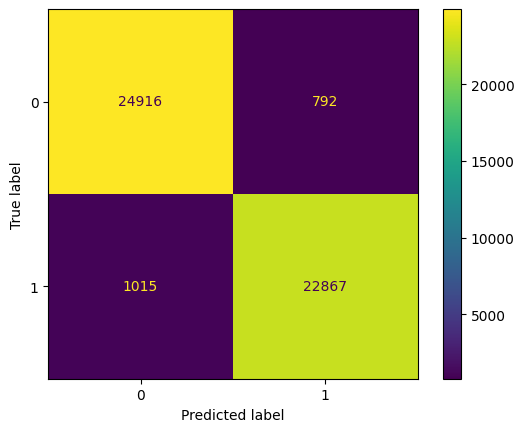

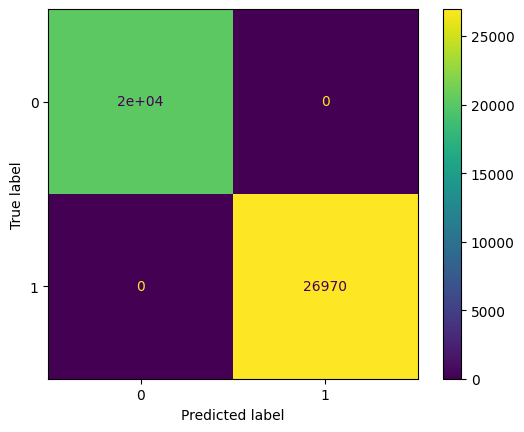

In [17]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
def train_no_feature_selection(dataset, model):
    """
    Predict using the testset and print the confusion matrix and classification report

    Parameters:
    x_test: the test set for input variables
    y_test: the test set for the target variable
    model: the trained model
    """
    model.fit(dataset["x_train_val"], dataset["y_train_val"])
    y_test_pred = model.predict(dataset["x_test"])
    print("\nTest Set Performance")
    cm = confusion_matrix(dataset["y_test"], y_test_pred)
    ConfusionMatrixDisplay(cm).plot()
    print(classification_report(dataset["y_test"], y_test_pred))
    

#create deepcopies of models so they can be reused
xgboost_mendeley_baseline_no_fs = deepcopy(xgboost_mendeley)
xgboost_phiusiil_baseline_no_fs = deepcopy(xgboost_phiusiil)

print('XGBoost Mendeley Results:')
train_no_feature_selection(mendeley_sets, xgboost_mendeley_baseline_no_fs)

print('XGBoost Phiusiil Results:')
train_no_feature_selection(phiusiil_sets, xgboost_phiusiil_baseline_no_fs)